# Module 2: Impact and Spreading

The original assignment ended at landing. It only asked for impact velocity and
position, and had a note saying dot size is roughly 2x the droplet diameter with
no model behind it.

This module was built from scratch for the inkjet application. It models:

1. Spreading factor beta = D_dot / d_droplet using the energy balance model
   of Pasandideh-Fard et al. (1996). This accounts for kinetic energy, surface
   energy, and viscous dissipation.
2. Contact angle dependence on substrate, which lets you compare the same ink
   on different media.
3. Satellite drop risk via Rayleigh-Plateau instability of the ink ligament.

Impact velocity from Module 1 feeds directly into this module.


In [1]:
import sys
from pathlib import Path

# Walk up from current directory until we find the project root
# (the folder that contains src/). Works regardless of where
# Cursor or Jupyter launches from.
_search = Path.cwd()
while _search != _search.parent:
    if (_search / 'src').exists():
        break
    _search = _search.parent

ROOT    = _search
SRC     = ROOT / 'src'
FIGURES = ROOT / 'results' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f'ROOT   : {ROOT}')
print(f'SRC    : {SRC}')
print(f'FIGURES: {FIGURES}')

import numpy as np
import matplotlib.pyplot as plt
from ink_properties import INKS, SUBSTRATES, weber, ohnesorge
from flight import simulate_flight
from impact import (
    spreading_factor, dot_diameter,
    sweep_viscosity, sweep_substrate,
    satellite_threshold,
    plot_dot_vs_we, plot_beta_vs_substrate, plot_oh_we_diagram
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

ROOT   : c:\
SRC    : c:\src
FIGURES: c:\results\figures


## 2.1 Full pipeline: flight into impact

Get impact velocity from Module 1, then compute dot size from Module 2.

In [2]:
ink = INKS['water_based_mid_visc']
sub = SUBSTRATES['coated_paper']
d   = 30e-6
v0  = 8.0

flight = simulate_flight(ink, d=d, v0=v0, angle_deg=90.0, y0=1e-3)
v_imp  = flight['v_impact']

beta  = spreading_factor(ink, sub, d, v_imp)
D_dot = dot_diameter(ink, sub, d, v_imp)
We    = weber(ink.rho, v_imp, d, ink.sigma)

print(f"Impact velocity   : {v_imp:.3f} m/s")
print(f"Weber number      : We = {We:.1f}")
print(f"Spreading factor  : beta = {beta:.2f}")
print(f"Droplet diameter  : d = {d*1e6:.1f} um")
print(f"Final dot diameter: D = {D_dot*1e6:.1f} um")
print(f"Dot gain          : {(D_dot/d - 1)*100:.1f}%")

Impact velocity   : 7.314 m/s
Weber number      : We = 52.7
Spreading factor  : beta = 2.75
Droplet diameter  : d = 30.0 um
Final dot diameter: D = 82.6 um
Dot gain          : 175.4%


## 2.2 Dot size vs. Weber number

Sweeping jetting velocity shows how faster jetting gives higher We and larger dots.
Left: effect of ink viscosity. Right: effect of substrate.

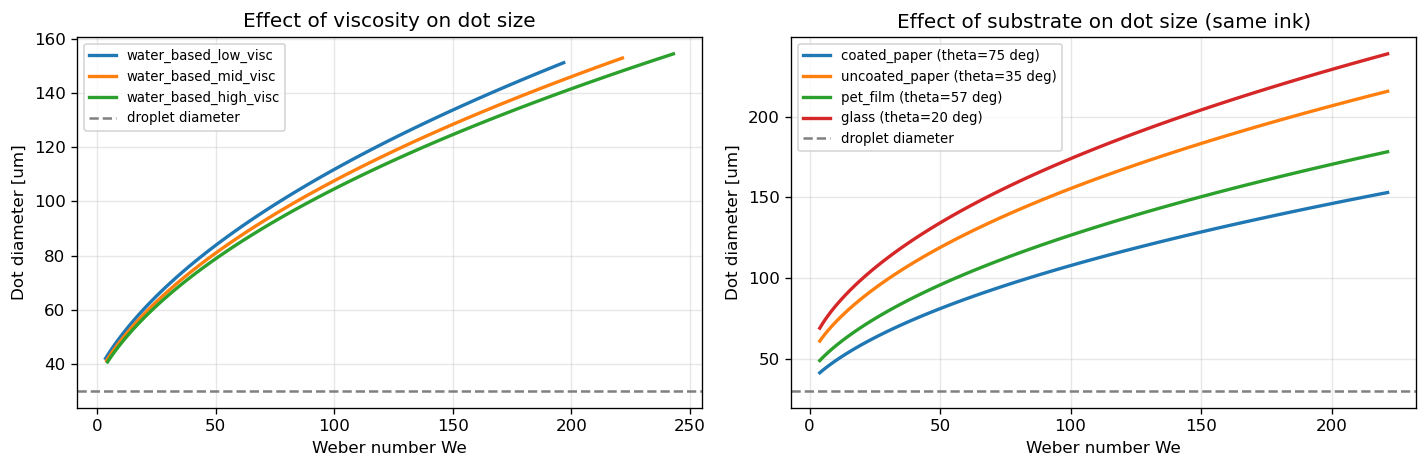

In [3]:
v_range = np.linspace(2.0, 15.0, 60)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, ink_ in INKS.items():
    if 'water' in name:
        We_vals = [weber(ink_.rho, v, d, ink_.sigma) for v in v_range]
        D_vals  = [dot_diameter(ink_, sub, d, v) * 1e6 for v in v_range]
        axes[0].plot(We_vals, D_vals, linewidth=2, label=name)

axes[0].axhline(d*1e6, color='gray', linestyle='--', label='droplet diameter')
axes[0].set_xlabel('Weber number We')
axes[0].set_ylabel('Dot diameter [um]')
axes[0].set_title('Effect of viscosity on dot size')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

ink = INKS['water_based_mid_visc']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for (name, substrate), col in zip(SUBSTRATES.items(), colors):
    We_vals = [weber(ink.rho, v, d, ink.sigma) for v in v_range]
    D_vals  = [dot_diameter(ink, substrate, d, v) * 1e6 for v in v_range]
    axes[1].plot(We_vals, D_vals, color=col, linewidth=2,
                 label=f"{name} (theta={substrate.theta_eq_deg:.0f} deg)")

axes[1].axhline(d*1e6, color='gray', linestyle='--', label='droplet diameter')
axes[1].set_xlabel('Weber number We')
axes[1].set_ylabel('Dot diameter [um]')
axes[1].set_title('Effect of substrate on dot size (same ink)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / '02_dot_size_sweeps.png', bbox_inches='tight')
plt.show()

## 2.3 Spreading factor across substrates

Same ink and jetting conditions on four different media. Coated paper has a higher
contact angle (75 deg) so the ink spreads less. Uncoated paper is more wettable
(35 deg) so the dot spreads more.

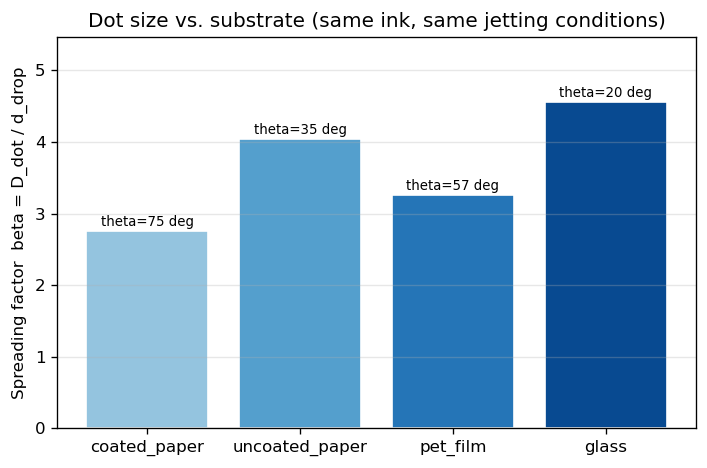

Spreading summary:
  coated_paper          beta = 2.75  D = 82.6 um
  uncoated_paper        beta = 4.04  D = 121.2 um
  pet_film              beta = 3.25  D = 97.6 um
  glass                 beta = 4.56  D = 136.7 um


In [4]:
ink   = INKS['water_based_mid_visc']
v_imp = simulate_flight(ink, d=d, v0=8.0, angle_deg=90.0)['v_impact']

results = sweep_substrate(ink, list(SUBSTRATES.values()), d, v_imp)

fig, ax = plt.subplots(figsize=(6, 4))
plot_beta_vs_substrate(results, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / '02_beta_vs_substrate.png', bbox_inches='tight')
plt.show()

print('Spreading summary:')
for name, r in results.items():
    print(f"  {name:20s}  beta = {r['beta']:.2f}  D = {r['D_dot_um']:.1f} um")

## 2.4 Satellite drop analysis

Ohnesorge number classification and Rayleigh-Plateau instability estimate.
The Oh-We diagram shows where each ink sits relative to the stable jetting window.
Note: the satellite diameter is an order-of-magnitude estimate, not a precise value.

Satellite drop analysis:
------------------------------------------------------------
water_based_low_visc            Oh=0.100  stable jetting window
  estimated satellite diameter: 59.6 um (rough estimate)
water_based_mid_visc            Oh=0.276  stable jetting window
  estimated satellite diameter: 59.6 um (rough estimate)
water_based_high_visc           Oh=0.492  stable jetting window
  estimated satellite diameter: 59.6 um (rough estimate)
uv_curable                      Oh=0.392  stable jetting window
  estimated satellite diameter: 59.6 um (rough estimate)


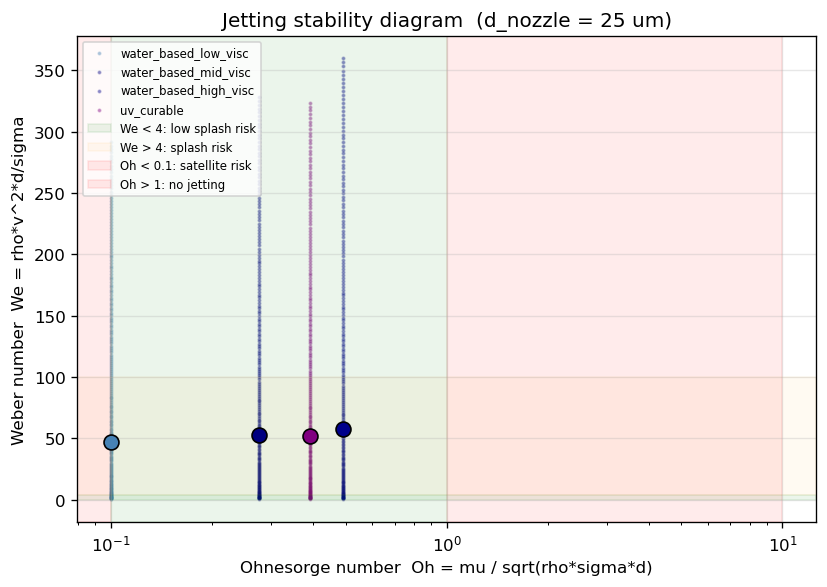

In [5]:
d_nozzle = 25e-6

print('Satellite drop analysis:')
print('-' * 60)
for name, ink_ in INKS.items():
    sat = satellite_threshold(ink_, d_nozzle)
    print(f"{name:30s}  Oh={sat['Oh']:.3f}  {sat['stability']}")
    if sat['d_sat_um'] > 0:
        print(f"  estimated satellite diameter: {sat['d_sat_um']:.1f} um (rough estimate)")

fig, ax = plt.subplots(figsize=(7, 5))
plot_oh_we_diagram(list(INKS.values()), d_nozzle=d_nozzle, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / '02_oh_we_diagram.png', bbox_inches='tight')
plt.show()